# West-Med Skytruth oil-slick detections

Query the [Cerulean](https://cerulean.skytruth.org) slick catalogue (the bundled
`skytruth` source) for the western Mediterranean (lon -6 to 20, lat 35 to 45)
over June 2023 and save the detections as an annotated Parquet file.

Skytruth is an **open** source — no credentials needed. Detections can be
sparse: widen the region or time window if a query returns none. Files are
written under `notebooks/cache/` (git-ignored).

In [1]:
from pathlib import Path

from IPython.display import display

import collekt
from collekt.core.config import get_config


def _repo_root(marker: str = "pyproject.toml") -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    return here


OUTPUT_ROOT = _repo_root() / "notebooks" / "cache" / "westmed_skytruth"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

config = get_config(overrides={"output": {"root": str(OUTPUT_ROOT)}})
request = collekt.Request(
    region=collekt.Region.from_bbox((-6.0, 20.0, 35.0, 45.0)),
    start="2023-06-01",
    end="2023-06-30",
)
request.as_dict()

{'region': {'west': -6.0, 'east': 20.0, 'south': 35.0, 'north': 45.0},
 'start': '2023-06-01T00:00:00Z',
 'end': '2023-06-30T23:59:59.999999Z',
 'variables': [],
 'sampling': '24h',
 'metadata': {}}

## Download

In [2]:
fetcher = collekt.Fetcher(
    request,
    config=config,
    use_datasources=["skytruth"],
    progress=lambda source, message: print(f"[{source}] {message}"),
)
result = fetcher.download()

print(result.summary)
for item in result.results:
    print(f"  {item.source}: {item.status.value} -> {item.path or item.message}")

Summary(planned=0, downloaded=0, reused=1, skipped=0, failed=0)
  skytruth: reused -> /Users/vitay/Research/Software/collekt/notebooks/cache/westmed_skytruth/20230601_20230630_24h_a55e6e20/skytruth/skytruth_20230601_20230630_a55e6e20.parquet


## Inspect the detections

The adapter writes an annotated Parquet file; read it back with polars.

In [3]:
import polars as pl

slicks = pl.read_parquet(result.files[0]) if result.files else None
if slicks is None:
    print("No detections for this query; widen the region or time window.")
else:
    print(f"{slicks.height} detections, {slicks.width} columns")
    columns = [c for c in ("id", "slick_timestamp", "machine_confidence", "area", "length") if c in slicks.columns]
    display(slicks.select(columns).head(10))

1817 detections, 26 columns


id,slick_timestamp,machine_confidence,area,length
i64,str,f64,f64,f64
3235225,"""2023-06-30T16:50:29""",0.659913,680736.729542,8161.658063
3199809,"""2023-06-30T16:50:04""",0.691745,2.1984e6,5023.407175
3199819,"""2023-06-30T16:50:04""",0.704283,942467.665621,9493.907921
3199815,"""2023-06-30T16:50:04""",0.758812,3.1815e6,13589.995509
3247203,"""2023-06-30T16:49:39""",0.982025,755045.142007,3840.495106
3247197,"""2023-06-30T16:49:39""",0.753659,493301.943414,6223.366884
3247194,"""2023-06-30T16:49:39""",0.880275,218632.471525,2242.203743
3247198,"""2023-06-30T16:49:39""",0.653114,804569.430016,13726.315034
3247201,"""2023-06-30T16:49:39""",0.63414,1.1532e6,25763.743415


## Machine-confidence distribution

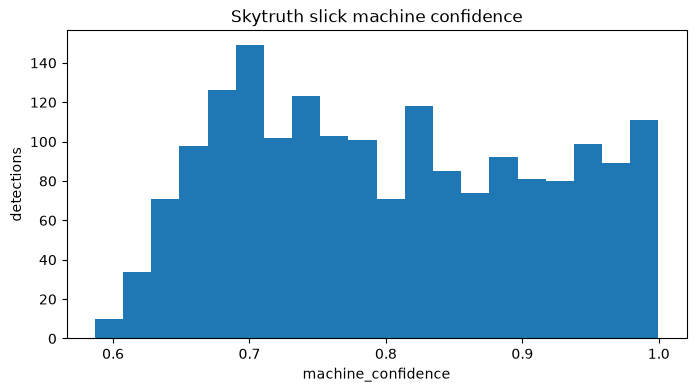

In [4]:
import matplotlib.pyplot as plt

if slicks is not None and "machine_confidence" in slicks.columns:
    values = slicks["machine_confidence"].drop_nulls().to_list()
    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=20)
    plt.xlabel("machine_confidence")
    plt.ylabel("detections")
    plt.title("Skytruth slick machine confidence")
    plt.show()